## Synthetic example for the MESA paper.
#### Objective: Showcase the effects of changes in the different STFT parameters. 

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy
import mesa

### Build the signal

In [2]:
sr = 800 # Hz
duration = 3.0 # s
N = int(sr*duration)
x = np.linspace(0, duration, N)

y1 = 10*np.cos(2*np.pi*15.0*x[0:N//3]) # Mono-mode signal
y2 = 5*np.cos(2*np.pi*10.0*x[N//3:N//3*2]) + 8*np.cos(2*np.pi*20.0*x[N//3:N//3*2]) # Bi-modal signal
y3 = 7*scipy.signal.chirp(x[0:N//3], f0=5.0, t1=duration//3, f1=50.0)

y = np.append(y1, y2, axis = 0)
y = np.append(y,  y3, axis = 0)


In [3]:
# STFT params
window_length = int(.75*sr)
hop = window_length//40
window = "blackman"
n_bins = window_length
center = True

In [4]:
from mesa.features import stft

D = stft(y,window_length,hop, center=center)
Sxx = np.abs(D)**2

(0.0, 3.0)

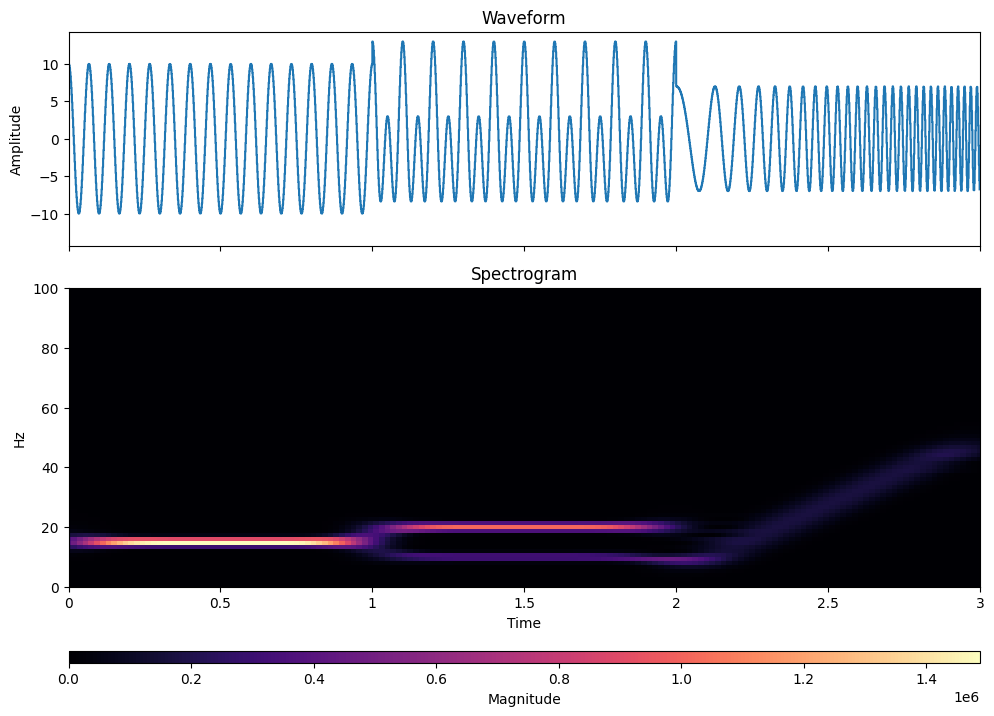

In [5]:
from mesa.visualization import spectrogram, dual_plot

fig = dual_plot(y, Sxx, sr, window_length, hop, center = center);
ax = fig.get_axes()
ax[1].set_ylim(0,100)
ax[1].set_xlim(0,3)

## Multi-signal

In [6]:
from mesa.visualization import spectrogram, dual_plot, multi_spectrogram, plot_signal

In [7]:
Y = np.zeros((5,3,len(x)))
Y = np.random.rand(2,4,len(x))

In [8]:
y, sr = librosa.load(librosa.ex('trumpet'), duration=3.5)

Y = np.zeros((5,3, len(y)))
R = np.random.rand(Y.shape[0], Y.shape[1])
R[0,0] = 1

for b in range(Y.shape[0]):
    for c in range(Y.shape[1]):
        channel = y * R[b,c]
        Y[b,c,:] = channel


In [9]:
from mesa.features import stft, stft_labels

# STFT params
window_length = int(0.05*sr)
hop = window_length//4
window = "blackman"
n_bins = window_length
center = True

D = stft(Y,window_length,hop, center=center)
Sxx = np.abs(D)**2
Sxx = librosa.amplitude_to_db(np.abs(D))

times, freqs = stft_labels(D, sr, hop, window_length)

In [10]:
D.shape, times.shape, freqs.shape

((5, 3, 552, 281), (281,), (552,))

In [11]:
a = np.array([])

a = a[...,np.newaxis]
a = a[...,np.newaxis]


a

array([], shape=(0, 1, 1), dtype=float64)

In [12]:
Sxx.shape, Y.shape, y.shape, y.shape[0]/sr, window_length, 1/0.01

((5, 3, 552, 281), (5, 3, 77175), (77175,), 3.5, 1102, 100.0)

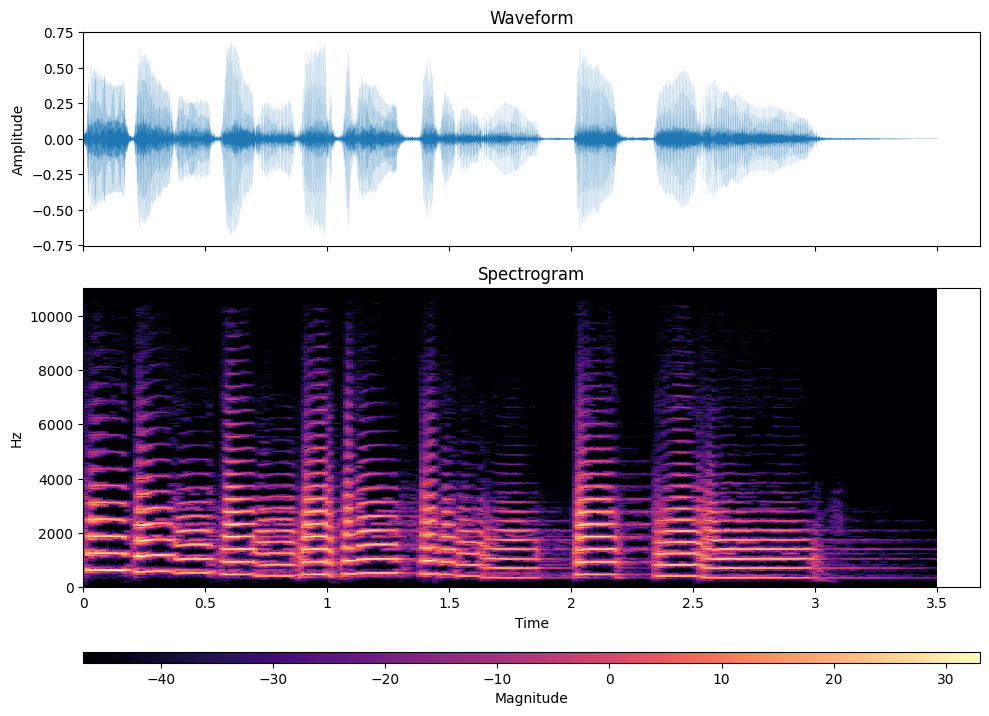

In [13]:
dual_plot(y, Sxx[0,0],sr,window_length,hop, center=center, cmap="magma");

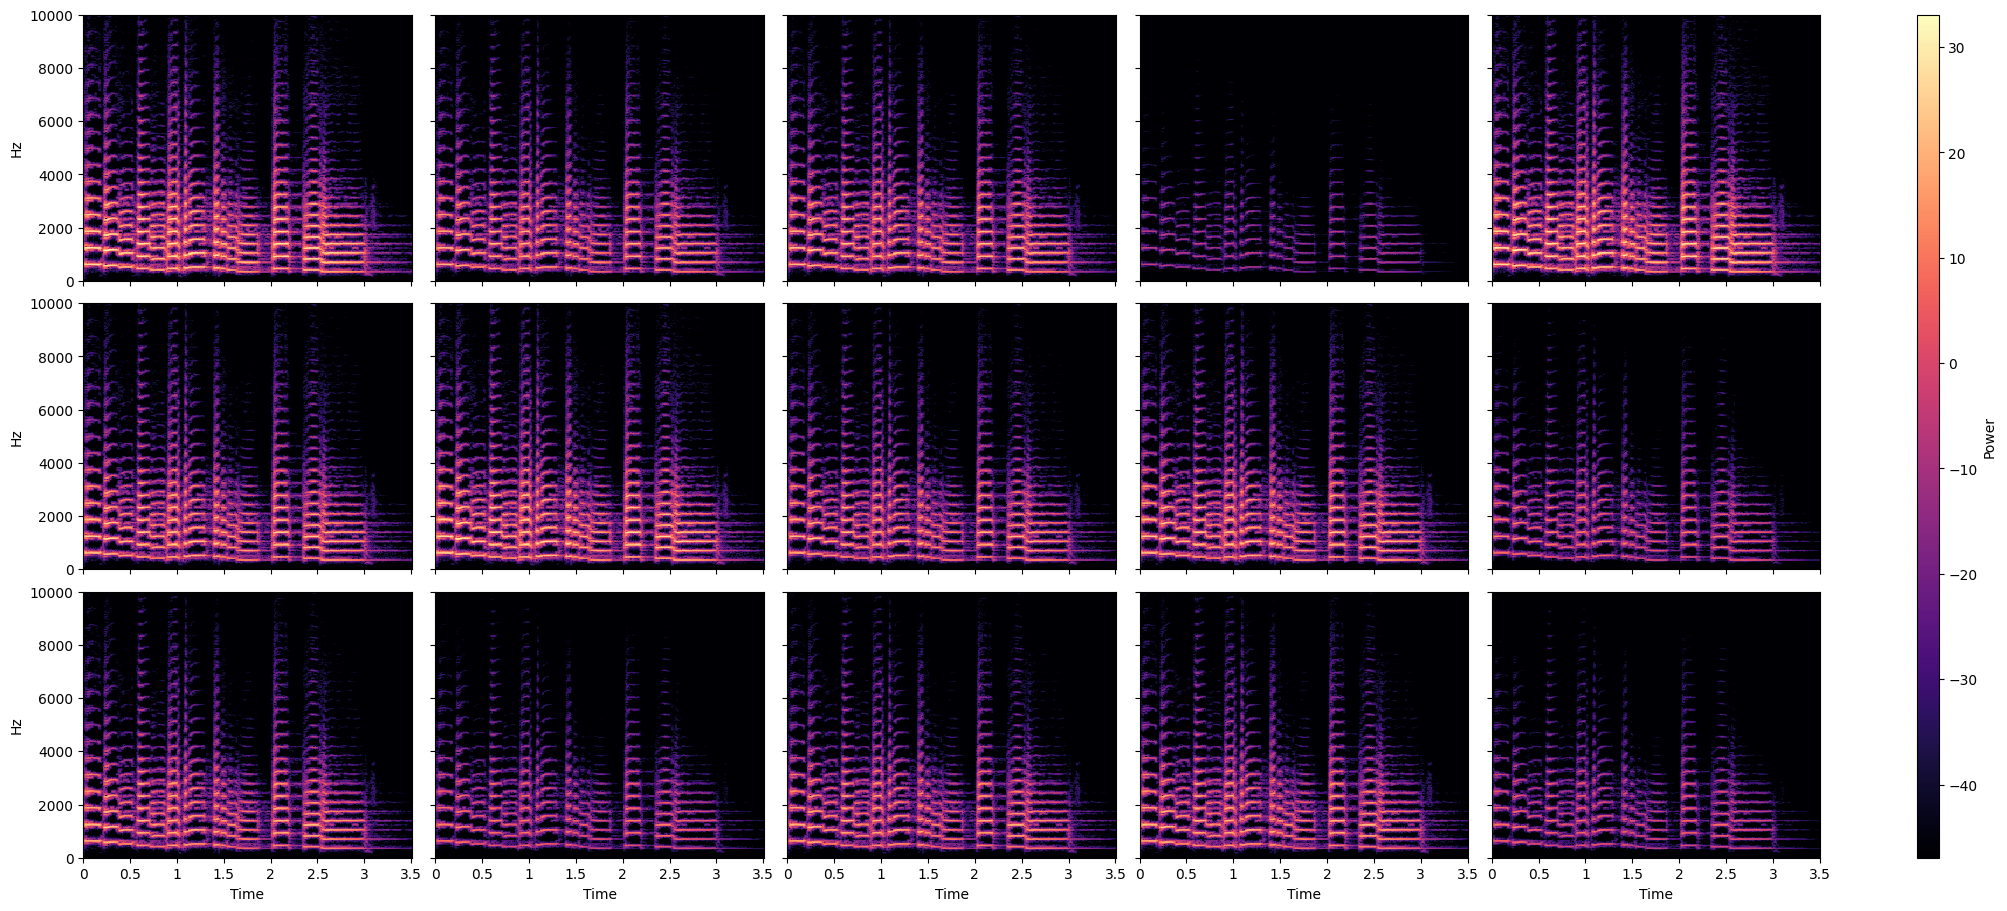

In [14]:

fig, axes = multi_spectrogram(Sxx, [1], [0],sr, window_length, hop=hop, cmap="magma")
# for ax in axes: ax.set_ylim(0,50)
for row in axes:
    row[0].set_ylim(0,10000)

In [15]:
Sxx.shape

(5, 3, 552, 281)

In [29]:
from mesa.fusion import unfold_2D

X_unfold,_ = unfold_2D(Sxx,rows=[3], cols=[2,1,0])

In [30]:
label_names = ["sensors", "channels", "freqs", "times"]
for i, name in enumerate(label_names):
    print(f"{name}: {Sxx.shape[i]}")

Sxx.shape, X_unfold.shape


sensors: 5
channels: 3
freqs: 552
times: 281


((5, 3, 552, 281), (281, 8280))

In [ ]:
from scipy.io import savemat

savemat(
    "trumpet.mat", {"data": X_unfold}
)